In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap
import glob
import json
import _utils

In [69]:
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

In [3]:
import seaborn as sns

In [4]:
import warnings # To suppress some warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

In [76]:
mpl.rcParams['xtick.labelsize'] = 7
mpl.rcParams['ytick.labelsize'] = 7
mpl.rcParams['axes.labelsize'] = 7
mpl.rcParams['legend.fontsize'] = 6
mpl.rcParams['legend.frameon'] = False
mpl.rcParams['axes.titlesize'] = 7

In [6]:
plt.rcParams['figure.dpi'] = 200

In [7]:
file_dir = "../processed_data/"

In [8]:
common_mask = xr.open_dataset(file_dir+"common_land_mask.nc")
def model_mask(ds):
    return(xr.where(common_mask.__xarray_dataarray_variable__ == 1, ds, np.nan))

combined_mask_dat = xr.open_dataset(file_dir+"combined_gauge_model_mask.nc")
def combined_mask(ds):
    return(xr.where(combined_mask_dat.__xarray_dataarray_variable__ >= 2, ds, np.nan))

In [9]:
N = (common_mask.__xarray_dataarray_variable__ == 1).sum().values
N_sub = (combined_mask_dat.__xarray_dataarray_variable__ >= 2).sum().values
print("N:", N, " N_sub:", N_sub)

N: 693  N_sub: 308


In [10]:
mon_pos_trends = pd.read_csv(file_dir+"model_positive_mon-p095_trends.csv", index_col=0)
day_pos_trends = pd.read_csv(file_dir+"model_positive_rx1day_trends.csv", index_col=0)

mon_obs_pos_trends = pd.read_csv(file_dir+"obs_positive_monthly_trends.csv", index_col=0)
day_obs_pos_trends = pd.read_csv(file_dir+"obs_positive_rx1day_trends.csv", index_col=0)

In [11]:
day_pos_trends["length"] = day_pos_trends["end_year"] - day_pos_trends["start_year"] +1
day_pos_trends["pos_percent"] = day_pos_trends["pos_trends_gaugemask"]/N_sub*100

day_obs_pos_trends["length"] = day_obs_pos_trends["end_year"] - day_obs_pos_trends["start_year"] +1
day_obs_pos_trends["pos_percent"] = day_obs_pos_trends["pos_trends_gaugemask"]/N_sub*100

In [12]:
mon_pos_trends["length"] = mon_pos_trends["end_year"] - mon_pos_trends["start_year"] +1
mon_pos_trends["pos_percent"] = mon_pos_trends["pos_trends_gaugemask"]/N_sub*100

mon_obs_pos_trends["length"] = mon_obs_pos_trends["end_year"] - mon_obs_pos_trends["start_year"] +1
mon_obs_pos_trends["pos_percent"] = mon_obs_pos_trends["pos_trends_gaugemask"]/N_sub*100

In [13]:
day_time_series_data = pd.read_csv(file_dir+"time_series_summary_rx1day.csv", index_col=0)
day_time_series_data["percent_above"] = day_time_series_data[["ecdf_pos_1_mask", "ecdf_neg_1_mask"]].sum(axis=1)/N_sub*100
day_time_series_data["percent_below"] = day_time_series_data[["ecdf_neg_0_mask", "ecdf_pos_0_mask"]].sum(axis=1)/N_sub*100
day_time_series_data["length"] = day_time_series_data["end_year"] - day_time_series_data["start_year"] + 1
day_time_series_data["percent_outside"] = day_time_series_data[["ecdf_pos_1_mask", "ecdf_pos_0_mask", "ecdf_neg_0_mask", "ecdf_neg_1_mask"]].sum(axis = 1)/N_sub*100

In [14]:
mon_time_series_data = pd.read_csv(file_dir+"time_series_summary_mon-p095.csv", index_col=0)
mon_time_series_data["percent_above"] = mon_time_series_data[["ecdf_pos_1_mask", "ecdf_neg_1_mask"]].sum(axis=1)/N_sub*100
mon_time_series_data["percent_below"] = mon_time_series_data[["ecdf_neg_0_mask", "ecdf_pos_0_mask"]].sum(axis=1)/N_sub*100
mon_time_series_data["length"] = mon_time_series_data["end_year"] - mon_time_series_data["start_year"] + 1
mon_time_series_data["percent_outside"] = mon_time_series_data[["ecdf_pos_1_mask", "ecdf_pos_0_mask", "ecdf_neg_0_mask", "ecdf_neg_1_mask"]].sum(axis = 1)/N_sub*100

In [15]:
daily_42year_startyears = np.arange(1950, 1980, 5)
daily_2016end_startyears = np.arange(1950, 1990, 5)

In [16]:
monthly_42year_startyears = np.append(np.arange(1930, 1980, 5), 1979)
monthly_2020end_startyears = np.append(np.arange(1930, 1990, 5), 1989)

In [17]:
a = mon_obs_pos_trends.loc[(mon_obs_pos_trends.length == 42) & (mon_obs_pos_trends.start_year).isin(monthly_42year_startyears)]
a_mod = mon_pos_trends.loc[(mon_pos_trends.length == 42) & (mon_pos_trends.start_year).isin(monthly_42year_startyears) & (mon_pos_trends.model == "cmip")]
b = day_obs_pos_trends.loc[(day_obs_pos_trends.length == 42) & (day_obs_pos_trends.start_year).isin(daily_42year_startyears)]
b_mod = day_pos_trends.loc[(day_pos_trends.length == 42) & (day_pos_trends.start_year).isin(daily_42year_startyears) & (day_pos_trends.model == "cmip")]

c = mon_time_series_data.loc[(mon_time_series_data.length == 42) & (mon_time_series_data.start_year).isin(monthly_42year_startyears)]
d = day_time_series_data.loc[(day_time_series_data.length == 42) & (day_time_series_data.start_year).isin(daily_42year_startyears)]

e = mon_obs_pos_trends.loc[(mon_obs_pos_trends.end_year == 2020) & (mon_obs_pos_trends.start_year).isin(monthly_2020end_startyears)]
e_mod = mon_pos_trends.loc[(mon_pos_trends.end_year == 2020) & (mon_pos_trends.start_year).isin(monthly_2020end_startyears) & (mon_pos_trends.model == "cmip")]
f = day_obs_pos_trends.loc[(day_obs_pos_trends.end_year == 2016) & (day_obs_pos_trends.start_year).isin(daily_2016end_startyears)]
f_mod = day_pos_trends.loc[(day_pos_trends.end_year == 2016) & (day_pos_trends.start_year).isin(daily_2016end_startyears) & (day_pos_trends.model == "cmip")]

g = mon_time_series_data.loc[(mon_time_series_data.end_year == 2020) & (mon_time_series_data.start_year).isin(monthly_2020end_startyears)]
h = day_time_series_data.loc[(day_time_series_data.end_year == 2016) & (day_time_series_data.start_year).isin(daily_2016end_startyears)]

In [18]:
mon_ecdf_test_summary = []
for start in np.arange(1930, 1990, 1):
    for end in np.arange(start+31, 2021):
        x = pd.read_csv(file_dir+"ecdf/gpcc_cmip-sub_mon-p095_"+str(start)+\
                        "-"+str(end)+"_ecdf_test_gauge_mask.csv", index_col = 0)
        dat = x
        dat["start_year"] = start
        dat["end_year"] = end
        dat["percent_above"] = dat[["pos_ecdf_1", "neg_ecdf_1"]].sum(axis=1)/N_sub*100
        dat["percent_below"] = dat[["pos_ecdf_0", "neg_ecdf_0"]].sum(axis=1)/N_sub*100
        dat["percent_outside"] = dat[["pos_ecdf_1", "neg_ecdf_1","pos_ecdf_0", "neg_ecdf_0"]].sum(axis=1)/N_sub*100
        dat["length"] = dat["end_year"] - dat["start_year"] + 1
        mon_ecdf_test_summary.append(dat)

mon_ecdf_test_summary = pd.concat(mon_ecdf_test_summary)

In [19]:
day_ecdf_test_summary = []
for start in np.arange(1950, 1986, 1):
    for end in np.arange(start+31, 2017):
        x = pd.read_csv(file_dir+"ecdf/regen_cmip-sub_rx1day_"+str(start)+\
                        "-"+str(end)+"_ecdf_test_gauge_mask.csv", index_col = 0)
        dat = x
        dat["start_year"] = start
        dat["end_year"] = end
        dat["percent_above"] = dat[["pos_ecdf_1", "neg_ecdf_1"]].sum(axis=1)/N_sub*100
        dat["percent_below"] = dat[["pos_ecdf_0", "neg_ecdf_0"]].sum(axis=1)/N_sub*100
        dat["percent_outside"] = dat[["pos_ecdf_1", "neg_ecdf_1","pos_ecdf_0", "neg_ecdf_0"]].sum(axis=1)/N_sub*100
        dat["length"] = dat["end_year"] - dat["start_year"] + 1
        day_ecdf_test_summary.append(dat)

day_ecdf_test_summary = pd.concat(day_ecdf_test_summary)

In [20]:
def calc_percentiles(df, group_var):
    
    result = df.groupby([group_var]).agg({
        'percent_outside': [lambda x: x.quantile(0.025), lambda x: x.quantile(0.25), lambda x: x.quantile(0.5), lambda x: x.quantile(0.75), lambda x: x.quantile(0.975)],
        'percent_above': [lambda x: x.quantile(0.025), lambda x: x.quantile(0.25), lambda x: x.quantile(0.5), lambda x: x.quantile(0.75), lambda x: x.quantile(0.975)], 
        'percent_below': [lambda x: x.quantile(0.025), lambda x: x.quantile(0.25), lambda x: x.quantile(0.5), lambda x: x.quantile(0.75), lambda x: x.quantile(0.975)]
    })
    
    result.columns = ['outside_p025', 'outside_p25', 'outside_p50', 'outside_p75', 'outside_p975',
                     'above_p025', 'above_p25', 'above_p50', 'above_p75', 'above_p975',
                     'below_p025', 'below_p25', 'below_p50', 'below_p75', 'below_p975']
    return(result)

In [22]:
d_test = day_ecdf_test_summary.loc[(day_ecdf_test_summary.length == 42) & (day_ecdf_test_summary.start_year).isin(daily_42year_startyears)]
h_test = day_ecdf_test_summary.loc[(day_ecdf_test_summary.end_year == 2016) & (day_ecdf_test_summary.start_year).isin(daily_2016end_startyears)]

In [23]:
c_test = mon_ecdf_test_summary.loc[(mon_ecdf_test_summary.length == 42) & (mon_ecdf_test_summary.start_year).isin(monthly_42year_startyears)]
g_test = mon_ecdf_test_summary.loc[(mon_ecdf_test_summary.end_year == 2020) & (mon_ecdf_test_summary.start_year).isin(monthly_2020end_startyears)]

In [24]:
d_test = calc_percentiles(d_test, "start_year")
h_test = calc_percentiles(h_test, "start_year")
c_test = calc_percentiles(c_test, "start_year")
g_test = calc_percentiles(g_test, "start_year")

In [25]:
ax_h = 0.65/4
ax_w = 0.2
positions = [
    [0.06, 0.17/4, ax_w, ax_h],  
    [0.1+ax_w, 0.17/4, ax_w, ax_h],
    [0.14+ax_w*2, 0.17/4, ax_w, ax_h],  
    [0.18+ax_w*3, 0.17/4, ax_w, ax_h]   
]

In [27]:
ax_h = 0.65/4
ax_w = 0.2
positions1 = [
    [0.06, 0.17/4+0.75, ax_w, ax_h],  
    [0.1+ax_w, 0.17/4+0.75, ax_w, ax_h],
    [0.14+ax_w*2, 0.17/4+0.75, ax_w, ax_h],  
    [0.18+ax_w*3, 0.17/4+0.75, ax_w, ax_h]   
]
positions2 = [
    [0.06, 0.17/4+0.5, ax_w, ax_h],  
    [0.1+ax_w, 0.17/4+0.5, ax_w, ax_h],
    [0.14+ax_w*2, 0.17/4+0.5, ax_w, ax_h],  
    [0.18+ax_w*3, 0.17/4+0.5, ax_w, ax_h]   
]
positions3 = [
    [0.06, 0.17/4+0.25, ax_w, ax_h],  
    [0.1+ax_w, 0.17/4+0.25, ax_w, ax_h],
    [0.14+ax_w*2, 0.17/4+0.25, ax_w, ax_h],  
    [0.18+ax_w*3, 0.17/4+0.25, ax_w, ax_h]   
]
positions4 = [
    [0.06, 0.17/4, ax_w, ax_h],  
    [0.1+ax_w, 0.17/4, ax_w, ax_h],
    [0.14+ax_w*2, 0.17/4, ax_w, ax_h],  
    [0.18+ax_w*3, 0.17/4, ax_w, ax_h]   
]

In [34]:
def plot_model_spread(df, ax, var): 
    ax.fill_between(df.index, df[var+"_p025"], df[var+"_p975"], color="lightgray")
    ax.fill_between(df.index, df[var+"_p25"], df[var+"_p75"], color="darkgray")
    ax.plot(df.index, df[var+"_p50"], color="dimgrey")

In [62]:
day_color1 = mpl.colormaps['RdBu'](0.92)
day_color2 = mpl.colormaps['RdBu'](0.92)
mon_color1 = mpl.colormaps['BrBG'](0.92)
mon_color2 = mpl.colormaps['BrBG'](0.92)

In [123]:
cmip6_shading = [
    Line2D([0], [0], color="dimgray", lw=1, label = "CMIP6 median"),
    Patch(color='darkgray', label='25-75% range'),
    Patch(color='lightgray', label='2.5-97.5% range'),
    ]

cmip6_lines = [
        Line2D([0], [0], color="darkgray", lw=1, label = "CMIP6 models"),
]

day_legend_marker = [
    Line2D([0], [0], color=day_color1, lw=1, label = "REGEN"),
    Line2D([0], [0], marker='P', color = "w", label='CPC', markerfacecolor=day_color1, markersize=6),
    Line2D([0], [0], marker='*', color = "w", label='MSWEP', markerfacecolor=day_color1, markersize=9)
]

day_legend_line = [
    Line2D([0], [0], color=day_color1, lw=1, label = "REGEN")
]

mon_legend_marker = [
    Line2D([0], [0], color=mon_color1, lw=1, label = "GPCC"),
    Line2D([0], [0], marker='P', color = "w", label='GPCP', markerfacecolor=mon_color1, markersize=6),
    Line2D([0], [0], marker='*', color = "w", label='MSWEP', markerfacecolor=mon_color1, markersize=9)
]


/var/folders/b6/_jnkr_p96xj02hcv5zspy3jh0000gp/T/ipykernel_9621/3757552565.py:12: UserWarning: 
The palette list has fewer values (1) than needed (37) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data = b_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0],
/var/folders/b6/_jnkr_p96xj02hcv5zspy3jh0000gp/T/ipykernel_9621/3757552565.py:52: UserWarning: 
The palette list has fewer values (1) than needed (37) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data = f_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0],
/var/folders/b6/_jnkr_p96xj02hcv5zspy3jh0000gp/T/ipykernel_9621/3757552565.py:100: UserWarning: 
The palette list has fewer values (1) than needed (44) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data = a_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0],
/var/folders/b6/_jnkr_p96xj02hcv5zspy3jh0000gp/T/ipykernel_9621/3757552565.py:149: UserWar

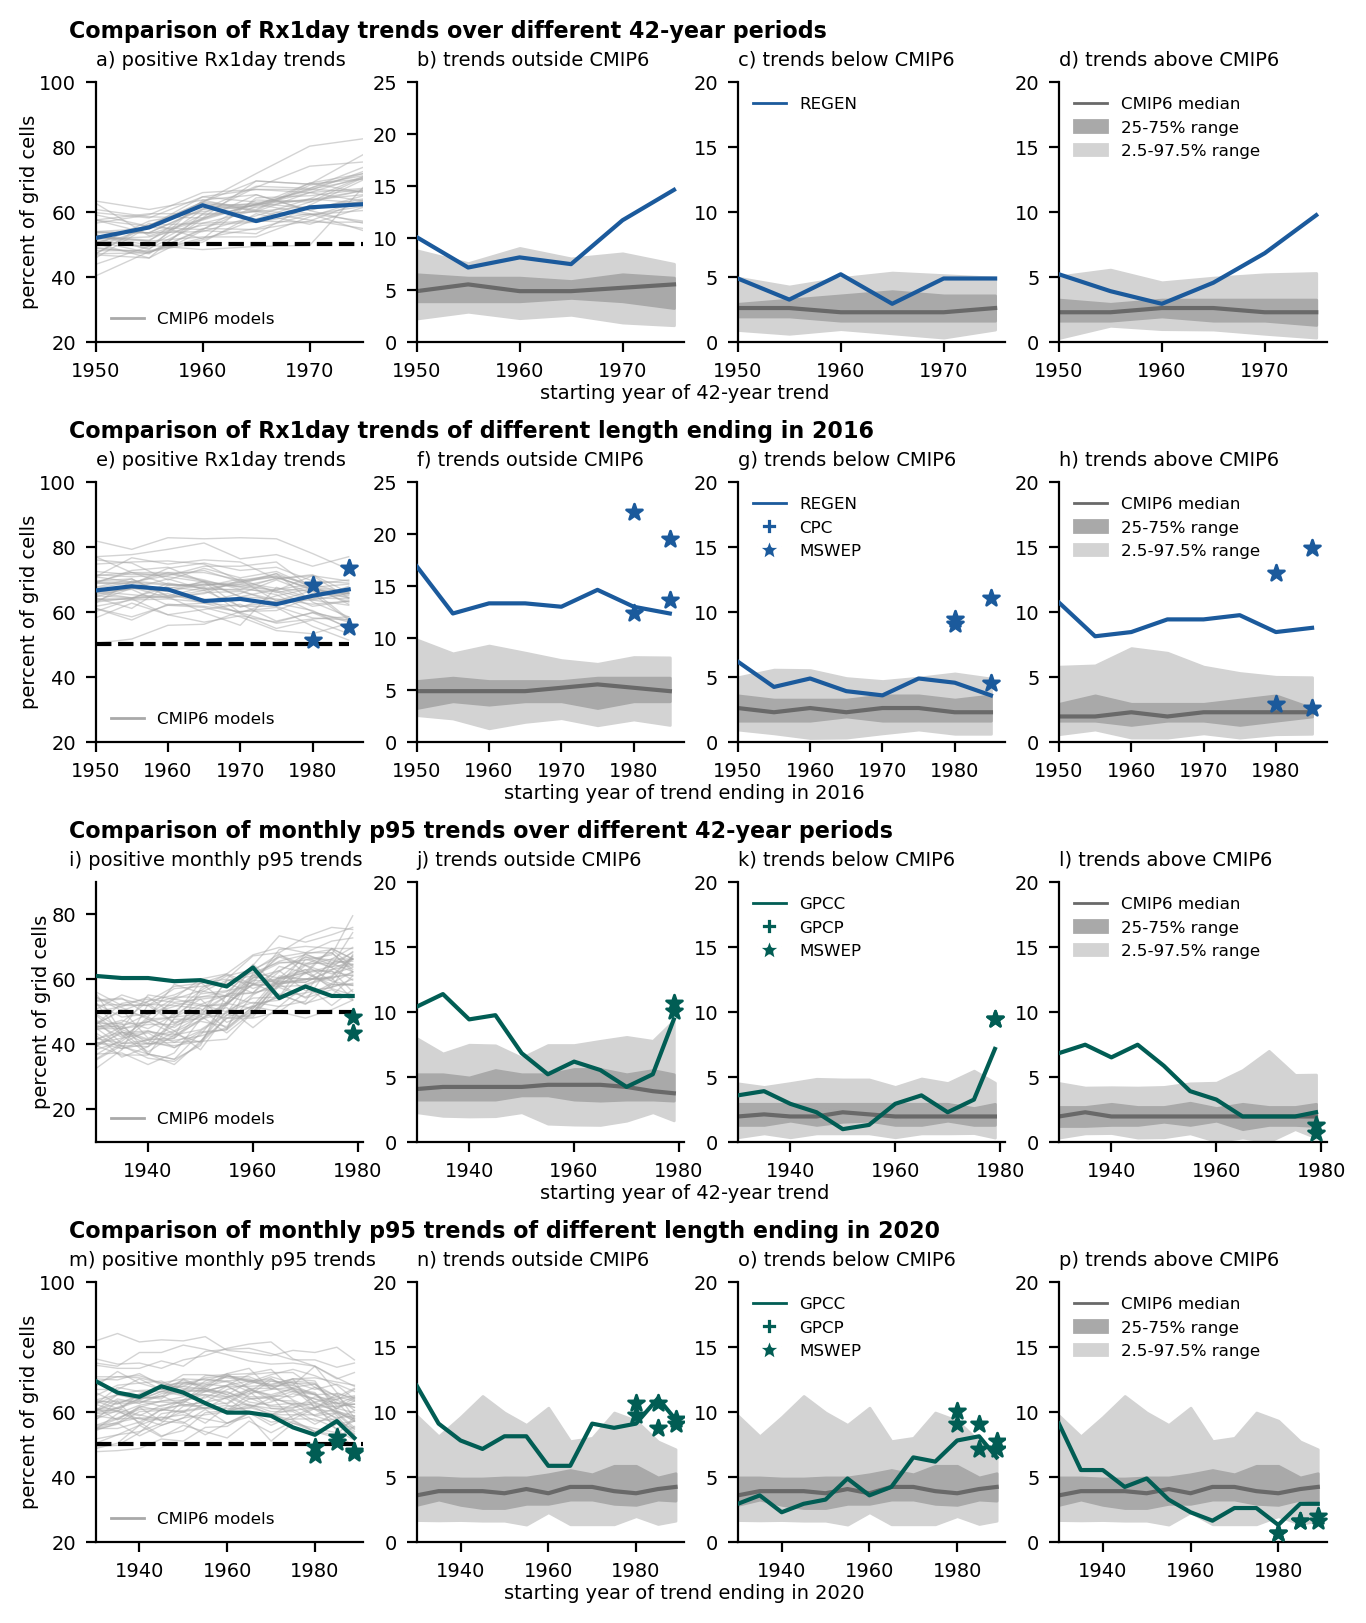

In [124]:
fig = plt.figure(figsize = (6.69, 8))

### -------- ###
### TOP ROW  ###
axes = [fig.add_axes(pos) for pos in positions1]

axes[0].text(-0.1, 1.17, "Comparison of Rx1day trends over different 42-year periods", fontsize = 8, fontweight = "bold", ha = "left", 
            transform = axes[0].transAxes)
axes[1].text(1, -0.22, 'starting year of 42-year trend', ha = "center", fontsize = 7, transform = axes[1].transAxes)

axes[0].plot(b.loc[b.obs == "regen"].start_year, b.loc[b.obs == "regen"].pos_percent, color = day_color1, zorder = 10)
sns.lineplot(data = b_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0], 
             palette = sns.color_palette(['darkgray']), alpha = 0.5, linewidth = 0.5, legend = False)
axes[0].hlines(50, 1950, 1975, linestyle = "--", colors = "black")
axes[0].set(ylim = (20, 100), xlim = (1950, 1975), xlabel = "")
axes[0].set_ylabel("percent of grid cells", labelpad=0)
axes[0].set_title("a) positive Rx1day trends", loc = "left")
axes[0].legend(handles=cmip6_lines, loc = "lower left")

sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1], color = day_color1, zorder = 10)
plot_model_spread(d_test, axes[1], 'outside')
axes[1].set(ylim = (0, 25), ylabel = "", xlim = (1950, 1976), xlabel = "")
axes[1].set_title("b) trends outside CMIP6", loc = "left")

sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2], color = day_color1, zorder = 10)
plot_model_spread(d_test, axes[2], 'below')
axes[2].set(ylim = (0, 20), ylabel = "", xlim = (1950, 1976), xlabel = "")
axes[2].set_title("c) trends below CMIP6", loc = "left")
axes[2].legend(handles=day_legend_line, loc = "upper left")

sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3], color = day_color1, zorder = 10)
plot_model_spread(d_test, axes[3], 'above')
axes[3].set(ylim = (0, 20), ylabel = "", xlim = (1950, 1976), xlabel = "")
axes[3].set_title("d) trends above CMIP6", loc = "left")
axes[3].legend(handles=cmip6_shading, loc = "upper left")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

### -------- ###
### SECOND ROW  ###
axes = [fig.add_axes(pos) for pos in positions2]
axes[0].text(-0.1, 1.17, "Comparison of Rx1day trends of different length ending in 2016", fontsize = 8, fontweight = "bold", ha = "left", 
            transform = axes[0].transAxes)
axes[1].text(1, -0.22, 'starting year of trend ending in 2016', fontsize = 7, transform = axes[1].transAxes, ha = "center")

axes[0].plot(f.loc[f.obs == "regen"].start_year, f.loc[f.obs == "regen"].pos_percent, color = day_color2, zorder = 10)
sns.lineplot(data = f_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0], 
             palette = sns.color_palette(['darkgray']), alpha = 0.5, linewidth = 0.5, legend = False)
axes[0].scatter(f.loc[f.obs.isin(["cpc", "mswep"])].start_year, 
                f.loc[f.obs.isin(["cpc", "mswep"])].pos_percent, marker = "*", color = day_color2, zorder = 10)
axes[0].hlines(50, 1950, 1985, linestyle = "--", colors = "black")
axes[0].set(ylim = (20, 100), xlim = (1950, 1987), xlabel = "")
axes[0].set_ylabel("percent of grid cells", labelpad=0)
axes[0].set_title("e) positive Rx1day trends", loc = "left")
axes[0].legend(handles=cmip6_lines, loc = "lower left")

sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1], color = day_color2, zorder = 10)
plot_model_spread(h_test, axes[1], 'outside')
axes[1].scatter(h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].start_year, 
                h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].percent_outside, marker = "*", color = day_color2, zorder = 10)
axes[1].set(ylim = (0, 25), xlim = (1950, 1987), ylabel = "", xlabel = "")
axes[1].set_title("f) trends outside CMIP6", loc = "left")

sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2], color = day_color2, zorder = 10)
plot_model_spread(h_test, axes[2], 'below')
axes[2].scatter(h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].start_year, 
                h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].percent_below, marker = "*", color = day_color2, zorder = 10)
axes[2].set(ylim = (0, 20), xlim = (1950, 1987), ylabel = "", xlabel = "")
axes[2].set_title("g) trends below CMIP6", loc = "left")
axes[2].legend(handles=day_legend_marker, loc = "upper left")

sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3], color = day_color2, zorder = 10)
plot_model_spread(h_test, axes[3], 'above')
axes[3].scatter(h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].start_year, 
                h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].percent_above, marker = "*", color = day_color2, zorder = 10)
axes[3].set(ylim = (0, 20), xlim = (1950, 1987), ylabel = "", xlabel = "")
axes[3].set_title("h) trends above CMIP6", loc = "left")
axes[3].legend(handles=cmip6_shading, loc = "upper left")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

### -------- ###
### THIRD ROW  ###
axes = [fig.add_axes(pos) for pos in positions3]
axes[0].text(-0.1, 1.17, "Comparison of monthly p95 trends over different 42-year periods", fontsize = 8, fontweight = "bold", ha = "left", 
            transform = axes[0].transAxes)
axes[1].text(1, -0.22, 'starting year of 42-year trend', fontsize = 7, transform = axes[1].transAxes, ha = "center")

axes[0].plot(a.loc[a.obs == "gpcc"].start_year, a.loc[a.obs == "gpcc"].pos_percent, color = mon_color1, zorder = 10)
sns.lineplot(data = a_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0], 
             palette = sns.color_palette(['darkgray']), alpha = 0.5, linewidth = 0.5, legend = False)
axes[0].scatter(a.loc[a.obs.isin(["gpcp", "mswep"])].start_year, 
                a.loc[a.obs.isin(["gpcp", "mswep"])].pos_percent, marker = "*", color = mon_color1, zorder = 10)
axes[0].hlines(50, 1930, 1979, linestyle = "--", colors = "black")
axes[0].set_ylabel("percent of grid cells", labelpad=0)
axes[0].set(ylim = (10, 90), xlim = (1930, 1981), xlabel = "")
axes[0].set_title("i) positive monthly p95 trends", x = -0.1, ha = "left")
axes[0].legend(handles=cmip6_lines, loc = "lower left")

sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1], color = mon_color1, zorder = 10)
plot_model_spread(c_test, axes[1], 'outside')
axes[1].scatter(c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].start_year, 
                c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].percent_outside, marker = "*", color = mon_color1, zorder = 10)
axes[1].set(ylim = (0, 20), xlim = (1930, 1981), ylabel = "", xlabel = "")
axes[1].set_title("j) trends outside CMIP6", loc = "left")

sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2], color = mon_color1, zorder = 10)
plot_model_spread(c_test, axes[2], 'below')
axes[2].scatter(c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].start_year, 
                c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].percent_below, marker = "*", color = mon_color1, zorder = 10)
axes[2].set(ylim = (0, 20), xlim = (1930, 1981), ylabel = "", xlabel = "")
axes[2].set_title("k) trends below CMIP6", loc = "left")
axes[2].legend(handles=mon_legend_marker, loc = "upper left")

sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3], color = mon_color1, zorder = 10)
plot_model_spread(c_test, axes[3], 'above')
axes[3].scatter(c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].start_year, 
                c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].percent_above, marker = "*", color = mon_color1, zorder = 10)
axes[3].set(ylim = (0, 20), xlim = (1930, 1981), ylabel = "", xlabel = "")
axes[3].set_title("l) trends above CMIP6", loc = "left")
axes[3].legend(handles=cmip6_shading, loc = "upper left")


for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

### -------- ###
### BOTTOM ROW  ###
axes = [fig.add_axes(pos) for pos in positions4]
axes[0].text(-0.1, 1.17, "Comparison of monthly p95 trends of different length ending in 2020", fontsize = 8, fontweight = "bold", 
             ha = "left", transform = axes[0].transAxes)
axes[1].text(1, -0.22, 'starting year of trend ending in 2020', fontsize = 7, transform = axes[1].transAxes, ha = "center")

axes[0].plot(e.loc[e.obs == "gpcc"].start_year, e.loc[e.obs == "gpcc"].pos_percent, color = mon_color2, zorder = 10)
sns.lineplot(data = e_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0], 
             palette = sns.color_palette(['darkgray']), alpha = 0.5, linewidth = 0.5, legend = False)
axes[0].scatter(e.loc[e.obs.isin(["gpcp", "mswep"])].start_year, 
                e.loc[e.obs.isin(["gpcp", "mswep"])].pos_percent, marker = "*", color = mon_color2, zorder = 10)
axes[0].axhline(50, linestyle = "--", c = "black")
axes[0].set(ylim = (20, 100), xlim = (1930, 1991), xlabel = "")
axes[0].set_ylabel("percent of grid cells", labelpad=0)
axes[0].set_title("m) positive monthly p95 trends", x = -0.1, ha = "left")
axes[0].legend(handles=cmip6_lines, loc = "lower left")

sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1], color = mon_color2, zorder = 10)
plot_model_spread(g_test, axes[1], 'outside')
axes[1].scatter(g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].start_year, 
                g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].percent_outside, marker = "*", color = mon_color2, zorder = 10)
axes[1].set(ylim = (0, 20), xlim = (1930, 1991), xlabel = "", ylabel = "")
axes[1].set_title("n) trends outside CMIP6", loc = "left")

sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2], color = mon_color2, zorder = 10)
plot_model_spread(g_test, axes[2], 'outside')
axes[2].scatter(g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].start_year, 
                g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].percent_below, marker = "*", color = mon_color2, zorder = 10)
axes[2].set(ylim = (0, 20), xlim = (1930, 1991), xlabel = "", ylabel = "")
axes[2].set_title("o) trends below CMIP6", loc = "left")
axes[2].legend(handles=mon_legend_marker, loc = "upper left")

sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3], color = mon_color2, zorder = 10)
plot_model_spread(g_test, axes[3], 'outside')
axes[3].scatter(g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].start_year, 
                g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].percent_above, marker = "*", color = mon_color2, zorder = 10)
axes[3].set(ylim = (0, 20), xlim = (1930, 1991), xlabel = "", ylabel = "")
axes[3].set_title("p) trends above CMIP6", loc = "left")
axes[3].legend(handles=cmip6_shading, loc = "upper left")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig("../figures/fig4.pdf")

/tmp/ipykernel_290779/2303938275.py:9: UserWarning: 
The palette list has fewer values (1) than needed (37) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data = b_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0],


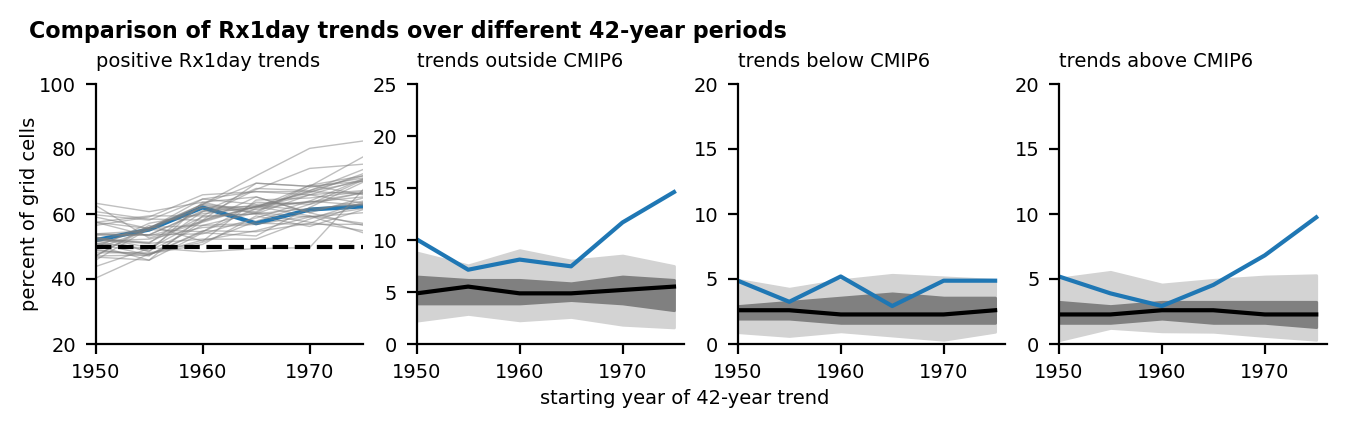

In [124]:
fig = plt.figure(figsize = (6.69, 2))
 
plt.suptitle("Comparison of Rx1day trends over different 42-year periods", fontsize = 8, fontweight = "bold", ha = "left", x = 0.01)
fig.supxlabel('starting year of 42-year trend', fontsize = 7, y = 0.01)

axes = [fig.add_axes(pos) for pos in positions]

axes[0].plot(b.loc[b.obs == "regen"].start_year, b.loc[b.obs == "regen"].pos_percent)
sns.lineplot(data = b_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0], 
             palette = sns.color_palette(['gray']), alpha = 0.5, linewidth = 0.5, legend = False)
axes[0].scatter(b.loc[b.obs.isin(["cpc", "mswep"])].start_year, 
                b.loc[b.obs.isin(["cpc", "mswep"])].pos_percent, marker = "*")
axes[0].hlines(50, 1950, 1975, linestyle = "--", colors = "black")
axes[0].set(ylim = (20, 100), xlim = (1950, 1975), xlabel = "")
axes[0].set_ylabel("percent of grid cells", labelpad=0)
axes[0].set_title("a) positive Rx1day trends", loc = "left")

sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1])
plot_model_spread(d_test, axes[1], 'outside')
axes[1].set(ylim = (0, 25), ylabel = "", xlim = (1950, 1976), xlabel = "")
axes[1].set_title("b) trends outside CMIP6", loc = "left")

sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2])
plot_model_spread(d_test, axes[2], 'below')
axes[2].set(ylim = (0, 20), ylabel = "", xlim = (1950, 1976), xlabel = "")
axes[2].set_title("c) trends below CMIP6", loc = "left")

sns.lineplot(data = d.loc[(d.obs == "regen") & (d.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3])
plot_model_spread(d_test, axes[3], 'above')
axes[3].set(ylim = (0, 20), ylabel = "", xlim = (1950, 1976), xlabel = "")
axes[3].set_title("d) trends above CMIP6", loc = "left")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig("../figures/time_series_42year_Rx1day_trends.pdf")

/tmp/ipykernel_290779/1941240661.py:9: UserWarning: 
The palette list has fewer values (1) than needed (37) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data = f_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0],


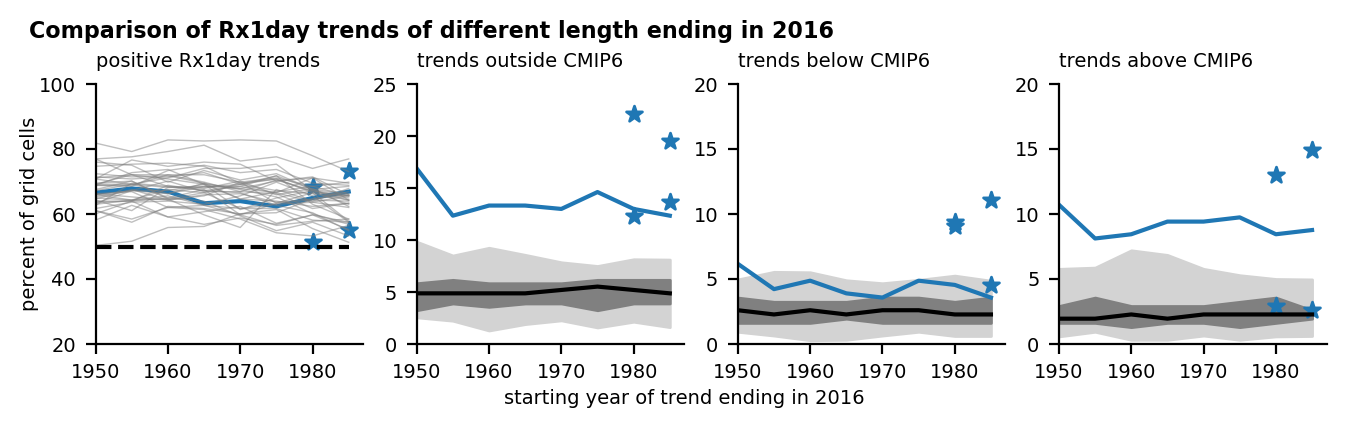

In [131]:
fig = plt.figure(figsize = (6.69, 2))

axes = [fig.add_axes(pos) for pos in positions]

plt.suptitle("Comparison of Rx1day trends of different length ending in 2016", fontsize = 8, fontweight = "bold", ha = "left", x = 0.01)
fig.supxlabel('starting year of trend ending in 2016', fontsize = 7, y = 0.01)

axes[0].plot(f.loc[f.obs == "regen"].start_year, f.loc[f.obs == "regen"].pos_percent)
sns.lineplot(data = f_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0], 
             palette = sns.color_palette(['gray']), alpha = 0.5, linewidth = 0.5, legend = False)
axes[0].scatter(f.loc[f.obs.isin(["cpc", "mswep"])].start_year, 
                f.loc[f.obs.isin(["cpc", "mswep"])].pos_percent, marker = "*")
axes[0].hlines(50, 1950, 1985, linestyle = "--", colors = "black")
axes[0].set(ylim = (20, 100), xlim = (1950, 1987), xlabel = "")
axes[0].set_ylabel("percent of grid cells", labelpad=0)
axes[0].set_title("e) positive Rx1day trends", loc = "left")

sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1])
plot_model_spread(h_test, axes[1], 'outside')
axes[1].scatter(h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].start_year, 
                h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].percent_outside, marker = "*")
axes[1].set(ylim = (0, 25), xlim = (1950, 1987), ylabel = "", xlabel = "")
axes[1].set_title("f) trends outside CMIP6", loc = "left")

sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2])
plot_model_spread(h_test, axes[2], 'below')
axes[2].scatter(h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].start_year, 
                h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].percent_below, marker = "*")
axes[2].set(ylim = (0, 20), xlim = (1950, 1987), ylabel = "", xlabel = "")
axes[2].set_title("g) trends below CMIP6", loc = "left")

sns.lineplot(data = h.loc[(h.obs == "regen") & (h.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3])
plot_model_spread(h_test, axes[3], 'above')
axes[3].scatter(h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].start_year, 
                h.loc[h.obs.isin(["cpc", "mswep"]) & (h.model == "cmip-sub")].percent_above, marker = "*")
axes[3].set(ylim = (0, 20), xlim = (1950, 1987), ylabel = "", xlabel = "")
axes[3].set_title("h) trends above CMIP6", loc = "left")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.savefig("../figures/time_series_2016end_Rx1day_trends.pdf")

/tmp/ipykernel_290779/1918913990.py:8: UserWarning: 
The palette list has fewer values (1) than needed (44) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data = a_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0],


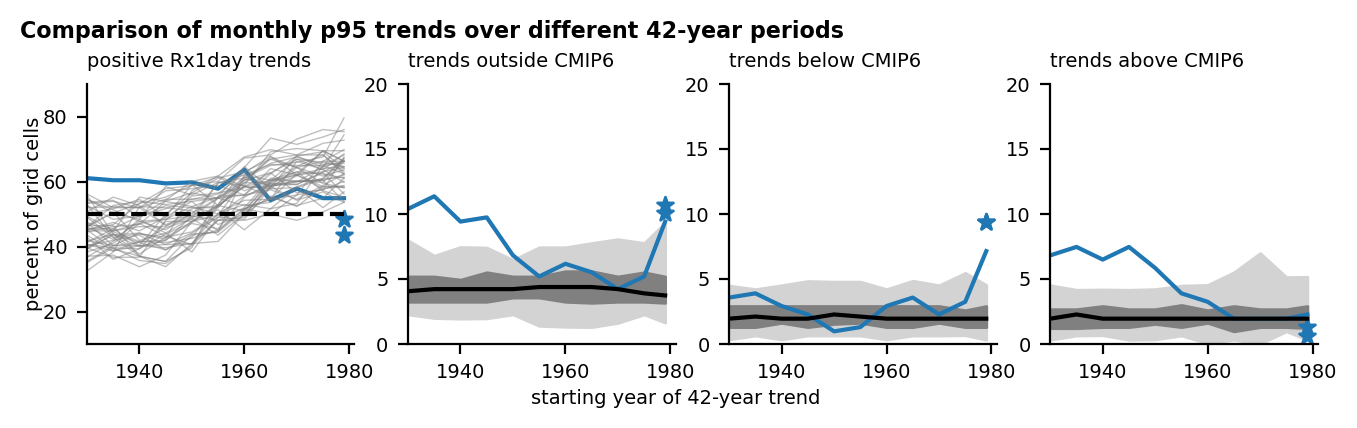

In [147]:
fig = plt.figure(figsize = (6.69, 2))

axes = [fig.add_axes(pos) for pos in positions]
plt.suptitle("Comparison of monthly p95 trends over different 42-year periods", fontsize = 8, fontweight = "bold", ha = "left", x = 0.01)
fig.supxlabel('starting year of 42-year trend', fontsize = 7, y = 0.01)

axes[0].plot(a.loc[a.obs == "gpcc"].start_year, a.loc[a.obs == "gpcc"].pos_percent)
sns.lineplot(data = a_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0], 
             palette = sns.color_palette(['gray']), alpha = 0.5, linewidth = 0.5, legend = False)
axes[0].scatter(a.loc[a.obs.isin(["gpcp", "mswep"])].start_year, 
                a.loc[a.obs.isin(["gpcp", "mswep"])].pos_percent, marker = "*")
axes[0].hlines(50, 1930, 1979, linestyle = "--", colors = "black")
axes[0].set_ylabel("percent of grid cells", labelpad=0)
axes[0].set(ylim = (10, 90), xlim = (1930, 1981), xlabel = "")
axes[0].set_title("i) positive Rx1day trends", loc = "left")

sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1])
plot_model_spread(c_test, axes[1], 'outside')
axes[1].scatter(c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].start_year, 
                c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].percent_outside, marker = "*")
axes[1].set(ylim = (0, 20), xlim = (1930, 1981), ylabel = "", xlabel = "")
axes[1].set_title("j) trends outside CMIP6", loc = "left")

sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2])
plot_model_spread(c_test, axes[2], 'below')
axes[2].scatter(c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].start_year, 
                c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].percent_below, marker = "*")
axes[2].set(ylim = (0, 20), xlim = (1930, 1981), ylabel = "", xlabel = "")
axes[2].set_title("k) trends below CMIP6", loc = "left")

sns.lineplot(data = c.loc[(c.obs == "gpcc") & (c.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3])
plot_model_spread(c_test, axes[3], 'above')
axes[3].scatter(c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].start_year, 
                c.loc[c.obs.isin(["gpcp", "mswep"]) & (c.model == "cmip-sub")].percent_above, marker = "*")
axes[3].set(ylim = (0, 20), xlim = (1930, 1981), ylabel = "", xlabel = "")
axes[3].set_title("l) trends above CMIP6", loc = "left")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

/tmp/ipykernel_290779/3708948620.py:8: UserWarning: 
The palette list has fewer values (1) than needed (44) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data = e_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0],


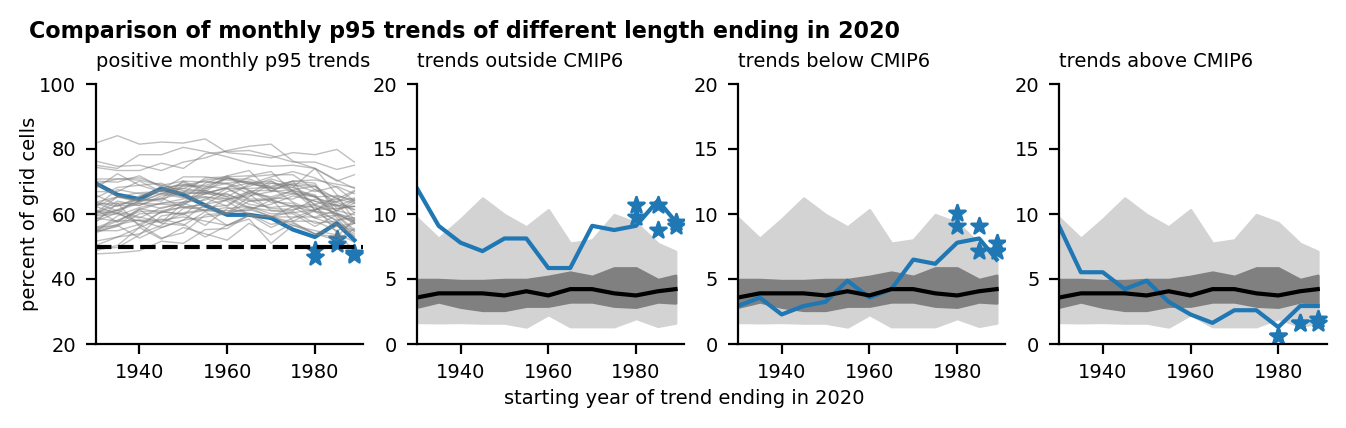

In [151]:
fig = plt.figure(figsize = (6.69, 2))

axes = [fig.add_axes(pos) for pos in positions]
plt.suptitle("Comparison of monthly p95 trends of different length ending in 2020", fontsize = 8, fontweight = "bold", ha = "left", x = 0.01)
fig.supxlabel('starting year of trend ending in 2020', fontsize = 7, y = 0.01)

axes[0].plot(e.loc[e.obs == "gpcc"].start_year, e.loc[e.obs == "gpcc"].pos_percent)
sns.lineplot(data = e_mod, x = "start_year", y = "pos_percent", hue = "sim", ax = axes[0], 
             palette = sns.color_palette(['gray']), alpha = 0.5, linewidth = 0.5, legend = False)
axes[0].scatter(e.loc[e.obs.isin(["gpcp", "mswep"])].start_year, 
                e.loc[e.obs.isin(["gpcp", "mswep"])].pos_percent, marker = "*")
axes[0].axhline(50, linestyle = "--", c = "black")
axes[0].set(ylim = (20, 100), xlim = (1930, 1991), xlabel = "")
axes[0].set_ylabel("percent of grid cells", labelpad=0)
axes[0].set_title("m) positive monthly p95 trends", loc = "left")

sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_outside", ax = axes[1])
plot_model_spread(g_test, axes[1], 'outside')
axes[1].scatter(g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].start_year, 
                g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].percent_outside, marker = "*")
axes[1].set(ylim = (0, 20), xlim = (1930, 1991), xlabel = "", ylabel = "")
axes[1].set_title("n) trends outside CMIP6", loc = "left")

sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_below", ax = axes[2])
plot_model_spread(g_test, axes[2], 'outside')
axes[2].scatter(g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].start_year, 
                g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].percent_below, marker = "*")
axes[2].set(ylim = (0, 20), xlim = (1930, 1991), xlabel = "", ylabel = "")
axes[2].set_title("o) trends below CMIP6", loc = "left")

sns.lineplot(data = g.loc[(g.obs == "gpcc") & (g.model == "cmip-sub")], 
         x = "start_year", y = "percent_above", ax = axes[3])
plot_model_spread(g_test, axes[3], 'outside')
axes[3].scatter(g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].start_year, 
                g.loc[g.obs.isin(["gpcp", "mswep"]) & (g.model == "cmip-sub")].percent_above, marker = "*")
axes[3].set(ylim = (0, 20), xlim = (1930, 1991), xlabel = "", ylabel = "")
axes[3].set_title("p) trends above CMIP6", loc = "left")

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [152]:
from matplotlib.backends.backend_pdf import PdfPages